# Exploratory Data Analysis (EDA)
### Visual exploration of the Stroke Prediction Dataset

This section provides graphical analysis to understand:
- Class imbalance
- Feature distributions
- Relationships between features and stroke occurance
- Potential predictive patterns

### Import Libraries:

In [27]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Load Dataset:

In [28]:
#Load the dataset
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
print("Shape:", df.shape)
df.head()

Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [29]:
print (df.columns)

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')


### Data Cleaning:

In [30]:
# Remove other gender row
df=df[df["gender"] != "Other"].copy()

#Create new BMI
bmi_median = df["bmi"].median()
df["bmi_new"] = df["bmi"].fillna(bmi_median)

print("Median BMI used:", bmi_median)
print("New shape:", df.shape)
print("Missing bmi:", df["bmi"].isna().sum())
print("Missing bmi_new:", df["bmi_new"].isna().sum())

Median BMI used: 28.1
New shape: (5109, 13)
Missing bmi: 201
Missing bmi_new: 0


### Target Class Distribution:

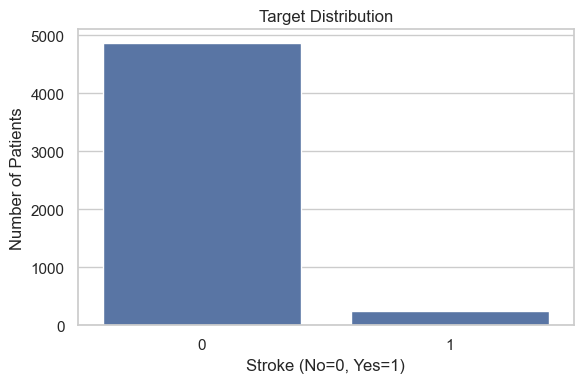

Stroke cases: 249
Total patient: 5109
Stroke percentage: 4.87%


In [31]:
#Target class distribution
plt.figure(figsize=(6,4))
sns.countplot(x="stroke", data=df)
plt.title("Target Distribution")
plt.xlabel("Stroke (No=0, Yes=1)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

#percentage
stroke_cases=df["stroke"].sum()
total_cases=len(df)
stroke_percentage=(stroke_cases/total_cases)*100

print(f"Stroke cases: {stroke_cases}")
print(f"Total patient: {total_cases}")
print(f"Stroke percentage: {stroke_percentage:.2f}%")

The target variable is highly imbalanced. Out of 5109 patients only 249 (4.87%) experience a stroke, while the vast majority belong to non-stroke class.

### Distribution of Categorical Features:

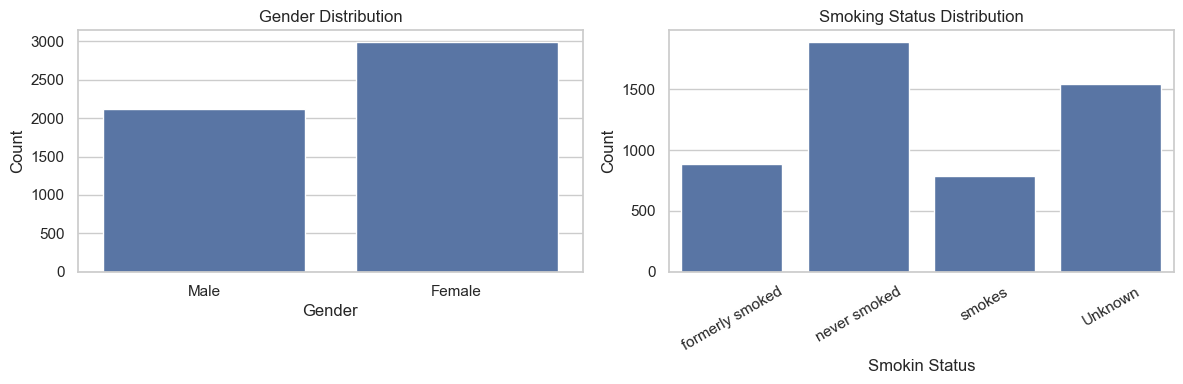

In [32]:
plt.figure(figsize=(12,4))

#Gender distribution
plt.subplot(1,2,1)
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

#Smoking status distribution
plt.subplot(1,2,2)
sns.countplot(x="smoking_status", data=df)
plt.title("Smoking Status Distribution")
plt.xlabel("Smokin Status")
plt.ylabel("Count")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

This analysis provides insight into the demographic and lifestyle characteristics of the dataset.
- The gender distribution shows that female patients slightly outnumber male patients in the dataset.
- The smoking status distribution indicates that most individuals have never smoked, while smaller groups include current smokers and former smokers. Additionally, a portion of the records is labeled as unknown, indicating missing or unspecified smoking information.

### Stroke Occurrence by Gender:

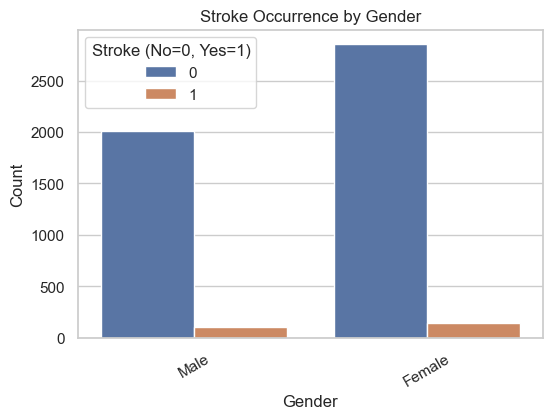

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender",hue="stroke", data=df)
plt.title("Stroke Occurrence by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Stroke (No=0, Yes=1)")
plt.show()

The comparison shows that bth male and female patients have stroke cases, although the majority of individuals in both groups did not exprerience a stroke. Female patients appear slightly more represented in the dataset overall, which explains the higher number of stroke cases among females. However, the difference between genders is relatively small, suggesting that gender alone may not be a strong predictor of stroke risk.

### Stroke Occurrence by Smoking Status:

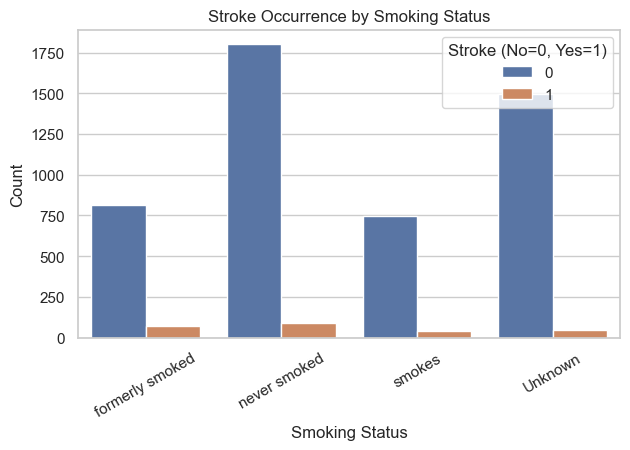

In [34]:
plt.figure(figsize=(7,4))
sns.countplot(x="smoking_status",hue="stroke", data=df)
plt.title("Stroke Occurrence by Smoking Status")
plt.xlabel("Smoking Status")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(title="Stroke (No=0, Yes=1)")
plt.show()

The plot shoes the distribution of stroke occurrence across different smoking categories. In all groups, non-stroke cases dominate due to the class imbalance in the dataset. However, stroke cases appear in multiple smoking categories, including individuals who never smoked and those who formerly smoked. Overall, smoking status may contribute to stroke risk but does not appear to be the strongest predictor.

### Distribution of Numerical Features:

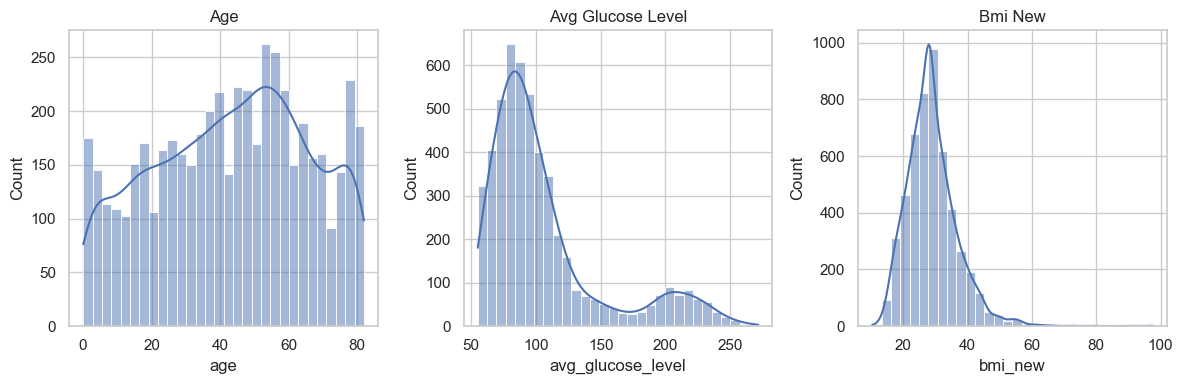

In [35]:
#Distribution of numerical features
numeric_features=["age", "avg_glucose_level", "bmi_new"]
plt.figure(figsize=(12,4))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1,3,i)
    sns.histplot(df[feature], bins=30, kde=True)
    plt.title(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

The histograms show the distribution of the main numerical features in the dataset:
- **Age** is relatively well distributed across different age groups.
- The **average glucose level** shows a right skewed distribution, indicating that most patients have moderate glucose levels while a smaller number have very high values.
- The **BMI** distribution is concentrated around the 20s to 30s with a few higher values suggesting the presence of outliers.

### Boxplots of Numerical Features:

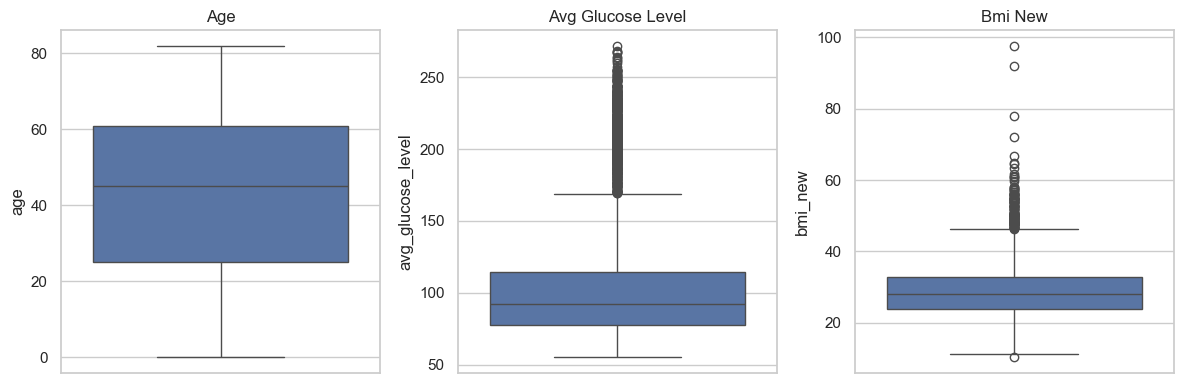

In [36]:
#Boxplots of numerical features
numeric_features=["age", "avg_glucose_level", "bmi_new"]
plt.figure(figsize=(12,4))
for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1,3,i)
    sns.boxplot(y=df[feature])
    plt.title(feature.replace("_", " ").title())

plt.tight_layout()
plt.show()

The boxplots illustrate the spread and variability of the main numerical variables in the dataset.
- **Age** appears relativly evenly distributed without extreme outliers.
- Both **average glucose level** and **BMI** show several high-value outliers, indicating that some patients have unusually high measurements.

These extreme values may represent individuals with increase heallth risk and should be considered during further analysis and preprocessing.

### Age and Stroke Relationship:

#### Age Distribution by Stroke Outcome:

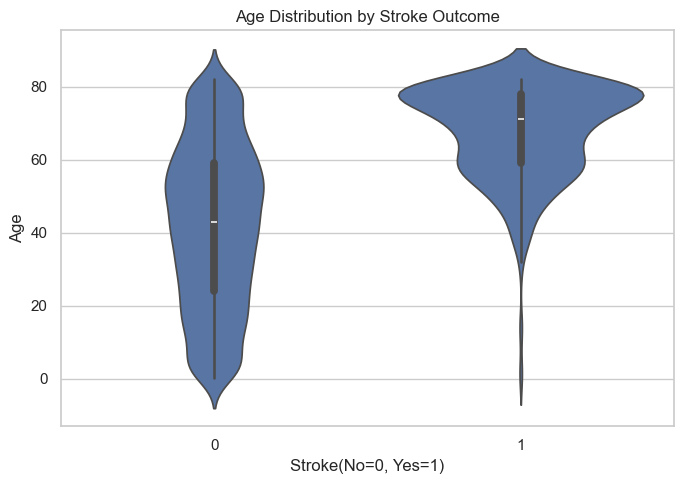

In [37]:
#Age vs Stroke
plt.figure(figsize=(7,5))
sns.violinplot(x="stroke", y="age", data=df)
plt.title("Age Distribution by Stroke Outcome")
plt.xlabel("Stroke(No=0, Yes=1)")
plt.ylabel("Age")

plt.tight_layout()
plt.show()

The violin plot demonstrates a clear pattern in stroke occurrence. Patients who experienced a stroke are noticeably older with the distribution concentrated between 60 and 80 years old and a higher median age compare to the non-stroke group. On the other hand, the non-stroke class spans a much wider age range, including a number of younger individuals. Although some overlap exist between groups, age appears to be one of the most influential predictors in the dataset.

#### Stroke Rate Across Age Groups:

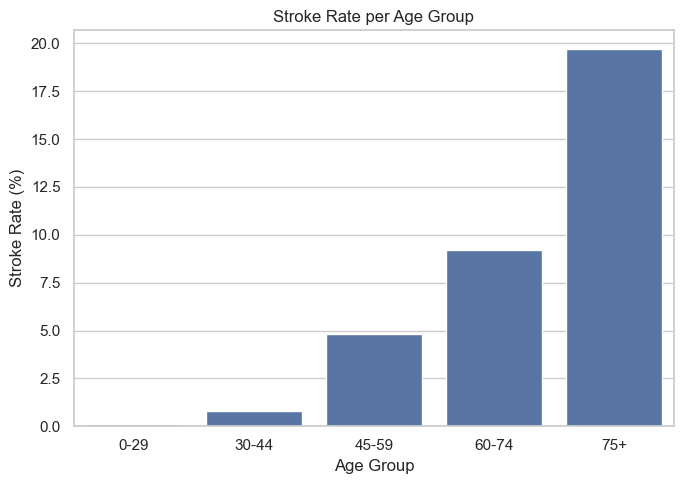

  Age Group  Stroke Rate (%)
0      0-29         0.132100
1     30-44         0.785855
2     45-59         4.829309
3     60-74         9.207459
4       75+        19.691120


In [38]:
#Stroke rate per age group
df["age_bin"]=pd.cut(df["age"],
                    bins=[0,30,45,60,75,85],
                    labels=["0-29", "30-44", "45-59", "60-74", "75+"],
                    right=False)

age_rate=(pd.crosstab(df["age_bin"], df["stroke"], normalize="index")*100)[1].reset_index()
age_rate.columns=["Age Group", "Stroke Rate (%)"]

plt.figure(figsize=(7,5))
sns.barplot(x="Age Group", y="Stroke Rate (%)", data=age_rate)
plt.title("Stroke Rate per Age Group")
plt.xlabel("Age Group")
plt.ylabel("Stroke Rate (%)")
plt.tight_layout()
plt.show()
print(age_rate)

The bar plot illustrates a clear and progressive increase in stroke prevelance with advancing age. Stroke rates are extremely low in individuals under 45 years old but rise substantially in older groups. Individuals aged 75 and older exhibit the highest stroke prevalence (19.7%), compared to only 0.13% in the age 0-29 group. This confirms age as one of the most influencial risk factors in the dataset and highlights its significant predictive importance.

### Stroke Rate by Glucose Level Category:

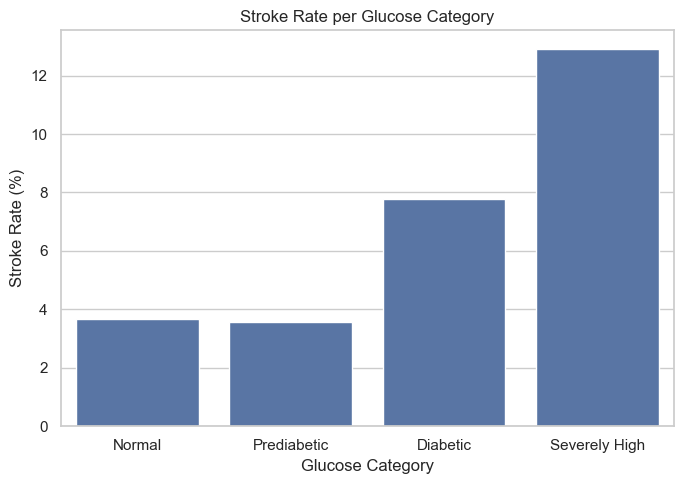

  Glucose Category  Stroke Rate (%)
0           Normal         3.663614
1      Prediabetic         3.571429
2         Diabetic         7.787611
3    Severely High        12.903226


In [39]:
#Glucose category stroke rate
df["glucose_bin"]=pd.cut(df["avg_glucose_level"],
                        bins=[0,90,125,200,300],
                        labels=["Normal", "Prediabetic", "Diabetic", "Severely High"],
                        right=False)

glucose_rate=(pd.crosstab(df["glucose_bin"], df["stroke"], normalize="index")*100)[1].reset_index()
glucose_rate.columns=["Glucose Category", "Stroke Rate (%)"]

plt.figure(figsize=(7,5))
sns.barplot(x="Glucose Category", y="Stroke Rate (%)", data=glucose_rate)
plt.title("Stroke Rate per Glucose Category")
plt.xlabel("Glucose Category")
plt.ylabel("Stroke Rate (%)")
plt.tight_layout()
plt.show()
print(glucose_rate)

The bar plot reveals a progressive increase in stroke prevalence with higher glucose rate. While individuals in the normal and prediabetic categories exhibit relatively similar an low stroke rates (around 3.6%), the rate nearly doubles in the diabetic group (7.8%) and rises further to approximately 12.9% in the severely high glucose category. This trend suggest a strong positive association between elevated glucose levels and stroke occurance.

### Stroke Rate by Hypertension Status:

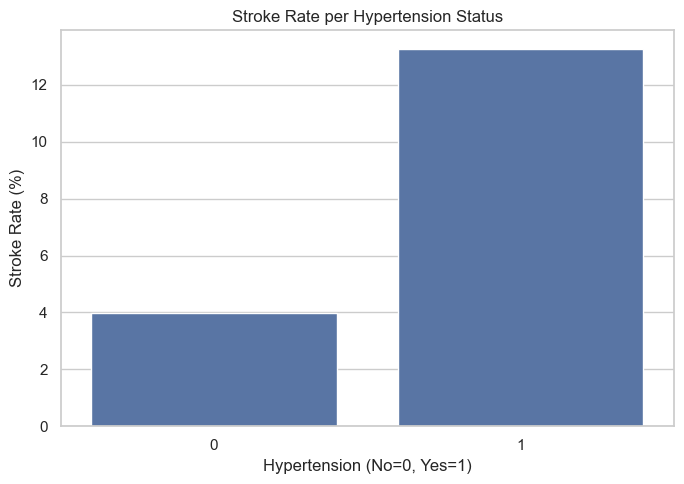

   Hypertension (No=0, Yes=1)  Stroke Rate (%)
0                           0         3.968770
1                           1        13.253012


In [40]:
# Hypertension vs Stroke rate
htn_rate=(pd.crosstab(df["hypertension"], df["stroke"], normalize="index")*100)[1].reset_index()
htn_rate.columns=["Hypertension (No=0, Yes=1)", "Stroke Rate (%)"]

plt.figure(figsize=(7,5))
sns.barplot(x="Hypertension (No=0, Yes=1)", y="Stroke Rate (%)", data=htn_rate)
plt.title("Stroke Rate per Hypertension Status")
plt.xlabel("Hypertension (No=0, Yes=1)")
plt.ylabel("Stroke Rate (%)")
plt.tight_layout()
plt.show()
print(htn_rate)

Patients with hypertension exhibit a substantially higher stroke prevalence (13.25%) compared to those without hypertansion (3.97%). This represents more than a threefold increase in stroke rate, supporting hypertansion as a significant risk factor within the dataset.

### Correlation Analysis of Numerical Features:

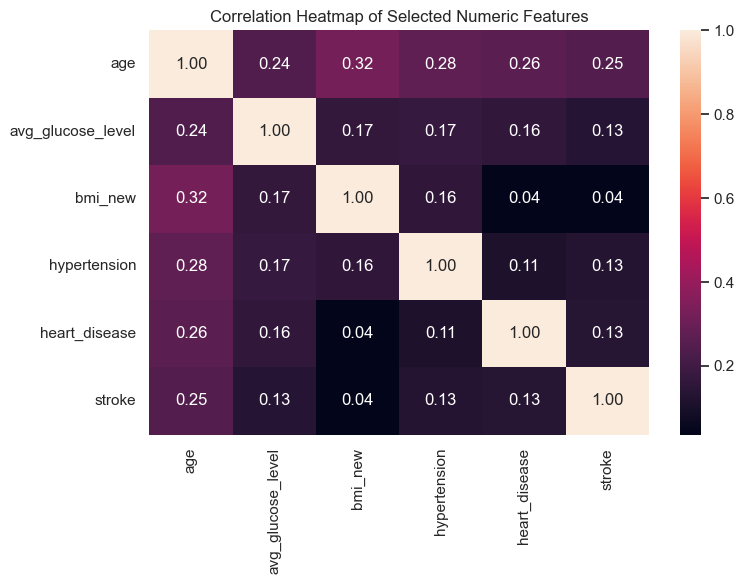

In [41]:
#Correlation Heatmap
numeric_cols=["age", "avg_glucose_level", "bmi_new", "hypertension", "heart_disease", "stroke"]
corr_matrix=df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f")
plt.title("Correlation Heatmap of Selected Numeric Features")
plt.tight_layout()
plt.show()

The correlation heatmap summarizes linear relationships among key numerical variables. Age demonstrates the strongest correlation with stroke (r=0.25), indicating its dominant predictive role. Hypertension, heart disease, and average glucose level exhibit moderate positive correlaions (r=0.13). BMI shows a week linear relationship with stoke (r=0.04), suggesting that its influence may be indirect or nonlinear.

### Pairwise Relationships Between Numerical Features:

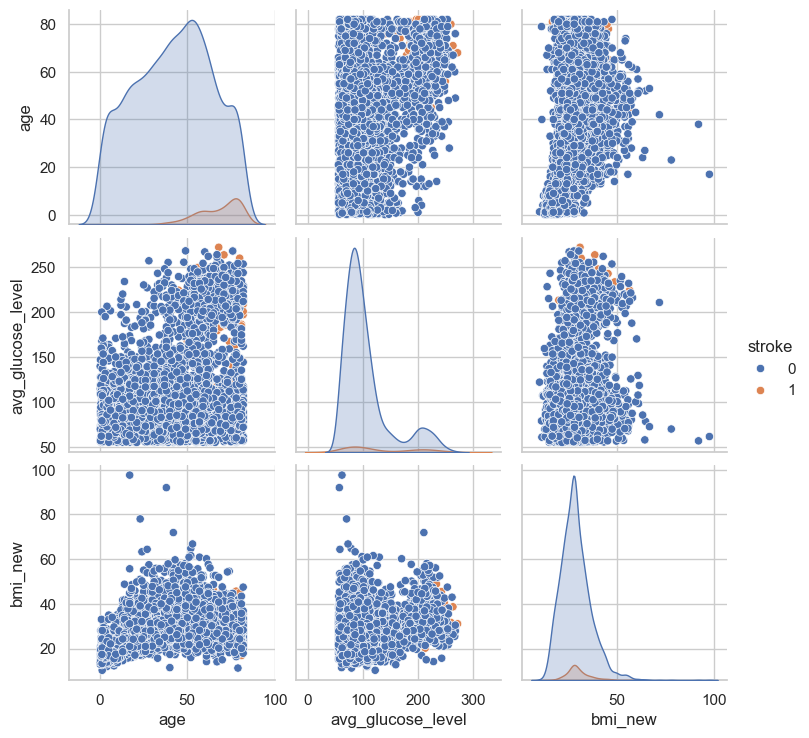

In [42]:
num_features=["age", "avg_glucose_level", "bmi_new", "stroke"]
sns.pairplot(df[num_features], hue="stroke")
plt.show()

The pairplot visualizes the relationship between the main numerical variables in the dataset (age, average glucose level, and BMI). the diagonical plots show the distribution of each feature, while the scatterplots illustrate pairwise relationships between variables. 

Stroke cases appear mostly among older individuals, supporting earlier observations that age is strongly associated with stroke occurance. In contrast, BMI and average glucose level show weaker visual seperation between stroke and non-stroke groups. Overall, the visualization suggests that age is one of the most influential predictors in the dataset, while other variables may contribute in combination with additional risk factors.

### Key Findings:
The exploratory data analysis revealed several important patterns in the dataset.
- The target variable is highly imbalanced, with stroke cases representing only a small proportion of the total observations.
- Age appears to be the most influential factor, as stroke cases occur primarly among older individuals and the stroke rate increases significantly across higher age groups.
- Elevated glucose levels and hypertension are aslo associated with higher stroke prevalence.
- BMI and gender show weaker direct relationships with stoke occurance.

Overall, these findings highlight the importance of demographic and health related variables in predictive stroke.